In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv(r'C:\Users\Lenovo\Desktop\Project4\data\Telco-Customer-Churn.csv')

Basic checks

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

here totalCharges must be numerical so wrong datatype

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [ ]:
#printing only numerical columns
num_col = df.select_dtypes(include=['Float64','int64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [10]:
#printing categorical columns only
cat_col=df.select_dtypes(include=['object'])
cat_col.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

here, total charges in not a categorical column

In [11]:
#to know all unique values within categorical columns
list = ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for x in list:
    print(x)
    print(df[x].unique())
    print()


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']



Total charges values are in float but are stored as string so we suspect that there are empty strings present in the data .

In [12]:
#replace empty strings with NAN
df.replace({" ":np.nan},inplace=True)
#yes, there were empty string values since i had does missing value check before but i got 0 . Now if i check i will get
#some missing values

In [13]:
#convert object to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
num_col

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

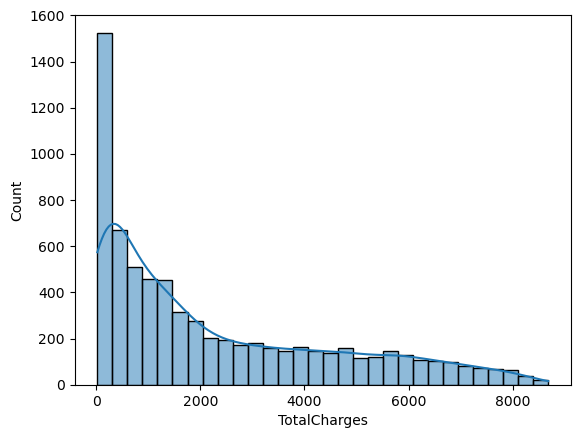

In [16]:
#checking the distribution of totalcharges
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.show()

In [17]:
#distribution is positively skewed so we will use median to replace the missing values 
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
#drop customerID
df=df.drop(['customerID'], axis=1)

<Axes: ylabel='MonthlyCharges'>

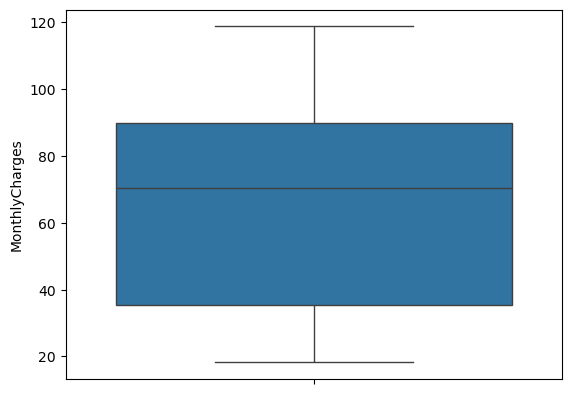

In [20]:
#Outliers analysis
sns.boxplot(df["MonthlyCharges"])

A boxplot was used to examine the distribution of MonthlyCharges and identify potential outliers. The analysis showed no observations outside the whisker boundaries, indicating the absence of significant outliers. Therefore, no outlier treatment was required for this variable.

Feature Engineering

In [21]:
#Create a new coloumn TenureGroup
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','12-24','24-48','48+']
)
#helps to analyze which customer tenure group churns the most.

In [22]:
df[['tenure', 'TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12
1,34,24-48
2,2,0-12
3,45,24-48
4,2,0-12


In [23]:
#create a new column spending level
df['SpendingLevel'] = pd.qcut(
    df['MonthlyCharges'],
    q=3,
    labels=['Low','Medium','High']
)
#helps to analyze are high-paying customers more likely to churn?

In [24]:
df[['MonthlyCharges','SpendingLevel']].head()

,MonthlyCharges,SpendingLevel
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Low
4,70.70,Medium


Exploratory Data analysis

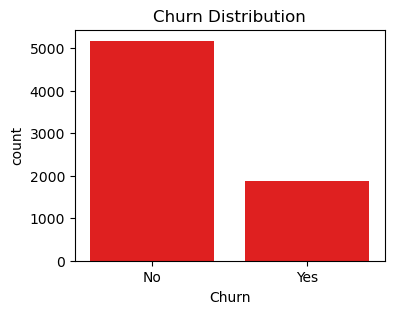

In [25]:
#What is the distrubution of Churn(Yes/No)?
plt.figure(figsize=(4,3))
sns.countplot(df, x='Churn', color='Red')
plt.title('Churn Distribution')
plt.show()


Insights
Customer retention: A large proportion of customers continue to use services which indicate relatively strong    retention.
Churn Rate: Significate number of customers has churned which suggest areas for improvement in customer satisfaction and service quality.
Opportunity for improvement: Reducing the churn rate could lead to better customer loyality and more stable revenue streams.

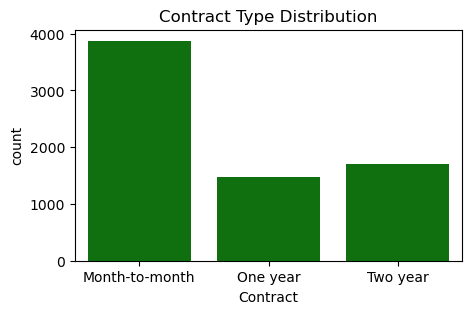

In [26]:
#How many customers fall in Contract type?
plt.figure(figsize=(5,3))
sns.countplot(df, x='Contract', color='Green')
plt.title('Contract Type Distribution')
plt.show()


Insight
Month-to-month has highest no. of customers: This type has the highest rate, with over 3000 customers.
One-year and two year has fewer cusotmers: This types has relatively less proportion.

Opportunity: The company might focus more on converting month-to-month customers into long term contract to increase retention and decrease churn rate.

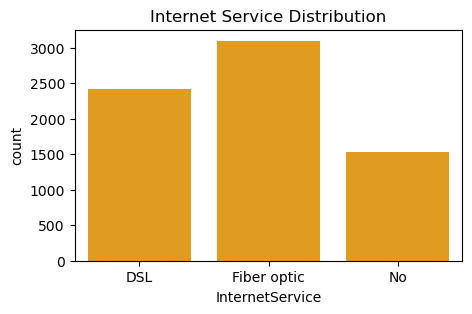

In [27]:
# How is the distribution for Internet service type?
plt.figure(figsize=(5,3))
sns.countplot(df, x='InternetService', color='orange')
plt.title('Internet Service Distribution')
plt.show()

Insights
Fiber optic is the mostly used internet service with DSL being the second.
Some does not have internet service at all.

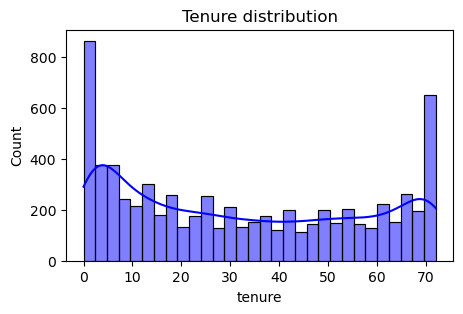

In [28]:
#how is the tenure distributed amoung customers?
plt.figure(figsize=(5,3))
sns.histplot(df['tenure'], bins=30, kde=True, color='blue')
plt.title('Tenure distribution')
plt.show()


Insights
High churn among new customers range 0-5 months, suggesting that many customers leave early.

Stable retention amoung long term customers.

Opportunity: The company may benifits more by focusing on retention programs targeting new customers to reduce churn rate.

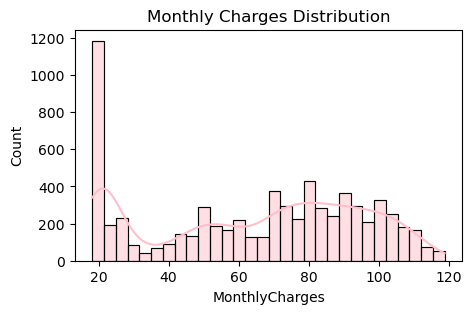

In [29]:
plt.figure(figsize=(5,3))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='pink')
plt.title('Monthly Charges Distribution')
plt.show()

Insights
Most customers are charged $20 monthly: indicates that the customers prefers low-cost plans.

Though there most customers are in low charged plans but there is a stable skewness in other highly paid plans too.


<function matplotlib.pyplot.show(close=None, block=None)>

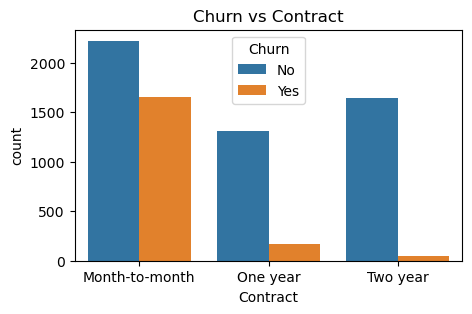

In [30]:
#how churn varies across different contract type?
plt.figure(figsize=(5,3))
sns.countplot(df, x='Contract', hue='Churn' )
plt.title('Churn vs Contract')
plt.show

Insights
Month-to-Month contract has high churn rate : It means that short term have the highest churn rate, indicating that customers with more flexible, short-term contracts are likely to churn.

One year and Two year has lower churn : These two has lower churn rate suggesting that longer commitment contracts help in retention.

Opportunity: Focus on converting month-to-month contracts to long term contracts.

<function matplotlib.pyplot.show(close=None, block=None)>

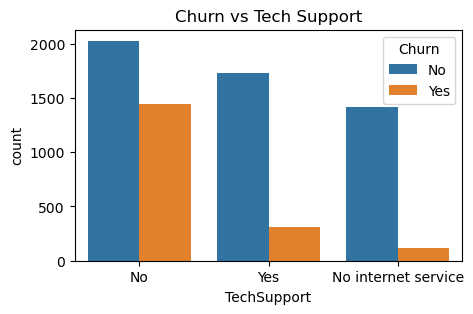

In [31]:
# Are customers with tech support have high chance of leaving?
plt.figure(figsize=(5,3))
sns.countplot(df, x='TechSupport', hue='Churn' )
plt.title('Churn vs Tech Support')
plt.show

Higher churn for customer with no tech support.
lower churn for customer with tech support.

<function matplotlib.pyplot.show(close=None, block=None)>

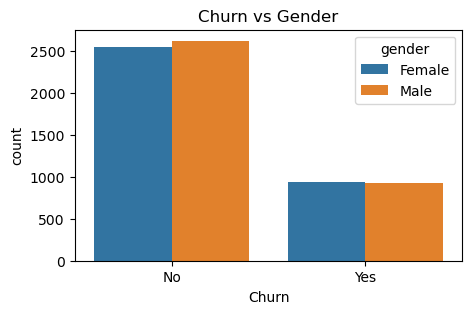

In [32]:
plt.figure(figsize=(5,3))
sns.countplot(df, x='Churn', hue='gender' )
plt.title('Churn vs Gender')
plt.show

This graph shows that the gender is not quite affecting the churn rate as both male and female has equal churn rate.

<Axes: xlabel='TenureGroup', ylabel='count'>

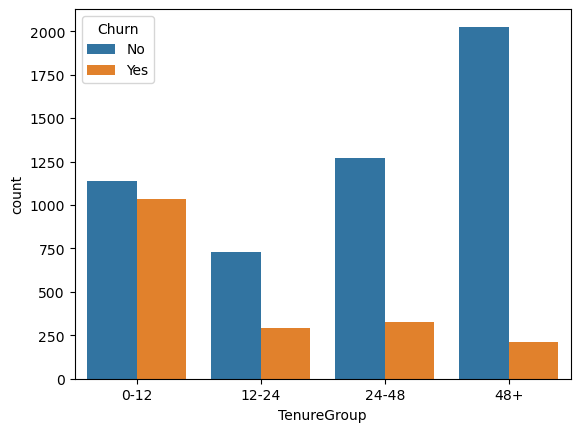

In [33]:
sns.countplot(x='TenureGroup', hue='Churn', data= df)

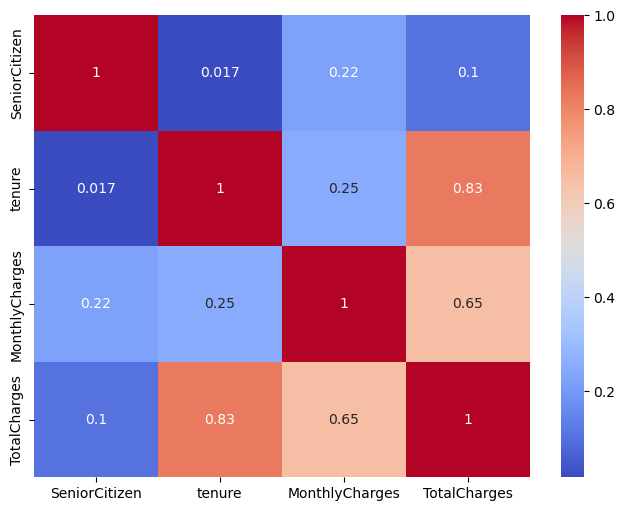

In [34]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

1. Tenure and total charges have a strong positive correlation. Long term customers contribute significantly to revenue.
2. Monthly charges and Total charges have moderate to strong positive correlation. 
2. Tenure and monthlycharges show a weak positive correlation. Long term customers are not neccessarily on expensive plans.

In [35]:
#correlation between churn and TenureGroup


In [38]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [39]:
from sqlalchemy import create_engine

#step1:connect to postgreSQL

username ="postgres"

password="amylee"

host="localhost"

port="4876"

database="telco_retention"



engine= create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")



#step2: load dataframe into postgreSQL

table_name= "customer"

df.to_sql(table_name,engine,if_exists="replace", index=False)



print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")  

Data successfully loaded into table 'customer' in database 'telco_retention'.


In [40]:
df.to_csv("cleaned_dataset.csv", index=False) 